<a href="https://colab.research.google.com/github/Priscilla-/SCiML_test_code/blob/main/SCIML_DMD_Koopman_SINDy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/Priscilla-/SCiML_test_code/blob/main/SCIML_DMD_Koopman_SINDy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data-Driven Discovery of Dynamical Systems --- DMD, Koopman, SINDy

**Companion notebook to the lecture _Data-Driven Discovery of Dynamical Systems_**
(Cambridge, *Scientific Machine Learning*, Dr P. Canizares).

We work through the three canonical examples from the slides, in the same order:

| Section | Method | Canonical example (lecture) |
|---|---|---|
| 1 | DMD            | 1-D travelling wave with two frequencies (sech profiles) |
| 2 | Koopman / EDMD | 2-D nonlinear toy $\dot x_1 = \mu x_1,\ \dot x_2 = \lambda(x_2 - x_1^2)$ |
| 3 | SINDy          | Lorenz-63                                                |

For DMD and Koopman/EDMD each section follows the same four steps:

1. **Generate data** from a known system.
2. **Implement the algorithm** step-by-step (fully annotated).
3. **Plot the highest modes / eigenfunctions** that the method recovers.
4. **Reconstruct the solution at a held-out time** (a time not in the training window).

For SINDy we show that the symbolic Lorenz right-hand side is recovered from
data.  The notebook is self-contained: only `numpy` and `matplotlib` are used.

References (lecture bibliography): Schmid 2010; Tu *et al.* 2014; Rowley *et al.*
2009; Williams *et al.* 2015 (EDMD); Mezic 2005; Brunton, Proctor, Kutz 2016
(SINDy); Brunton & Kutz 2022 (Ch. 7); Lusch, Kutz, Brunton 2018.


---
## 0. Setup

We use only the standard scientific-Python stack (NumPy + Matplotlib), both
pre-installed on Colab. No `scipy` is needed — we ship a 12-line RK4
integrator below.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({
    'figure.figsize': (8, 4.5),
    'figure.dpi': 110,
    'axes.grid':  True,
    'grid.alpha': 0.3,
    'font.size':  11,
})

def rk4(f, x0, t):
    """Classical fourth-order Runge--Kutta on a uniform grid `t`.

    Parameters
    ----------
    f  : callable  f(t, x) -> ndarray, RHS of the ODE.
    x0 : ndarray   initial state.
    t  : ndarray   uniform time grid.

    Returns
    -------
    X  : ndarray of shape (len(x0), len(t))   trajectory column-wise.
    """
    n   = len(t)
    dt  = t[1] - t[0]
    X   = np.empty((len(x0), n))
    X[:, 0] = x0
    for k in range(n - 1):
        tk, xk = t[k], X[:, k]
        k1 = f(tk,           xk)
        k2 = f(tk + dt/2,    xk + dt*k1/2)
        k3 = f(tk + dt/2,    xk + dt*k2/2)
        k4 = f(tk + dt,      xk + dt*k3)
        X[:, k+1] = xk + dt*(k1 + 2*k2 + 2*k3 + k4) / 6.0
    return X


---
# 1. Dynamic Mode Decomposition (DMD)

> **Idea.** Given snapshot pairs
> $\mathbf X = [\mathbf x_0, \dots, \mathbf x_{m-1}]$ and
> $\mathbf X' = [\mathbf x_1, \dots, \mathbf x_m]$, find the *best-fit
> linear* operator $\bf A^\star$ such that
> $\mathbf X' \approx \bf A^\star \mathbf X$.
> The Exact DMD algorithm of Tu *et al.* (2014) extracts this operator's
> spectrum from a thin SVD of $\mathbf X$ without ever forming $\bf
> A^\star$ explicitly.

The lecture's worked toy example is the 1-D travelling wave

$$u(x,t) \;=\; \operatorname{sech}(x + 3)\,e^{i\,2.3\,t} \;+\; 2\,\operatorname{sech}(x)\,\tanh(x)\,e^{i\,2.8\,t}.$$

It has two oscillatory components, each with its own spatial profile and its
own (purely imaginary) eigenvalue.  DMD should recover these two.


## 1.1 Data generation

* Spatial grid: $n = 256$ points on $x \in [-10, 10]$.
* Temporal grid: $m_{\text{train}} = 80$ snapshots on $t \in [0,\, 4\pi]$.
* We will keep $t = 5\pi$ (outside the training window) for the held-out
reconstruction in latter in Sec. 1.4.


In [21]:
# --- Spatial and temporal grids -----------------------------------
n_x        = 256
x_grid     = np.linspace(-10.0, 10.0, n_x)

m_train    = 80
t_train    = np.linspace(0.0, 4*np.pi, m_train)
dt_dmd     = t_train[1] - t_train[0]

# --- Two spatial profiles and two frequencies ---------------------
phi1_true   = 1.0 / np.cosh(x_grid + 3.0)              # sech(x+3)
phi2_true   = 2.0 / np.cosh(x_grid) * np.tanh(x_grid)  # 2 sech(x) tanh(x)
omega1_true = 1j * 2.3
omega2_true = 1j * 2.8

def u_true(t):
    """Ground truth: exact analytic solution u(x, t)
    for any (vector of) times t.
    """
    t = np.atleast_1d(t)
    return (phi1_true[:, None] * np.exp(omega1_true * t)
          + phi2_true[:, None] * np.exp(omega2_true * t))


In [18]:
# --- Build the snapshot matrix X (n_x x m_train) ------------------
X_data = u_true(t_train)
print('X_data shape =', X_data.shape, '   (n_x, m_train)')



X_data shape = (256, 80)    (n_x, m_train)


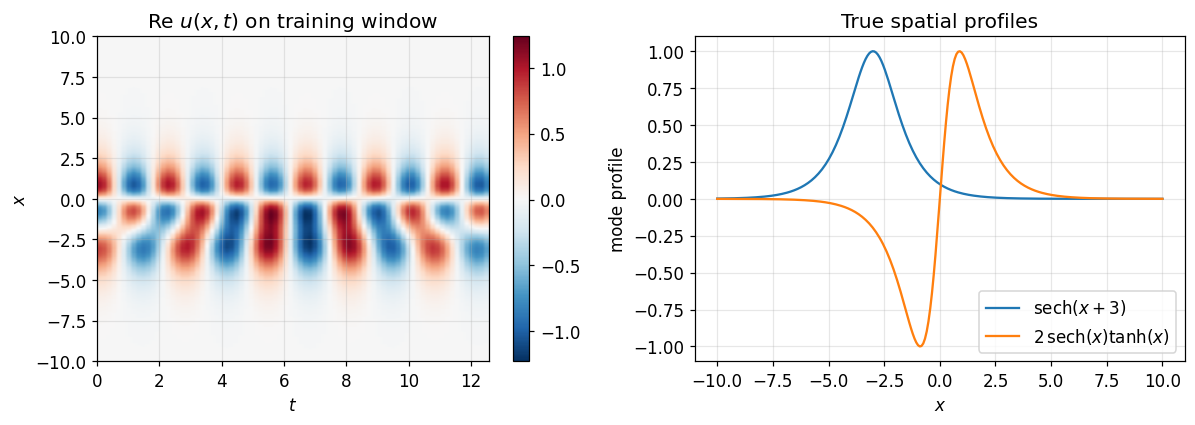

In [22]:
# --- Visualise real part as space-time heatmap ----------
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
im = ax[0].imshow(X_data.real, aspect='auto', origin='lower',
                  extent=[t_train[0], t_train[-1], x_grid[0], x_grid[-1]],
                  cmap='RdBu_r')
ax[0].set_xlabel('$t$'); ax[0].set_ylabel('$x$')
ax[0].set_title(r'$\operatorname{Re}\,u(x,t)$ on training window')
plt.colorbar(im, ax=ax[0])

ax[1].plot(x_grid, phi1_true.real, label=r'$\operatorname{sech}(x+3)$')
ax[1].plot(x_grid, phi2_true.real, label=r'$2\,\operatorname{sech}(x)\tanh(x)$')
ax[1].set_xlabel('$x$'); ax[1].set_ylabel('mode profile')
ax[1].set_title('True spatial profiles'); ax[1].legend()
fig.tight_layout(); plt.show()

## 1.2 Exact DMD algorithm

Following Tu *et al.* 2014:

1. Build the shifted snapshot pair $\mathbf X = [\mathbf x_0,\dots,\mathbf x_{m-1}]$,
   $\mathbf X' = [\mathbf x_1,\dots,\mathbf x_m]$.
2. Compute the thin SVD $\mathbf X = \mathbf U\,\boldsymbol\Sigma\,\mathbf V^*$
   and truncate to rank $r$.
3. Project: $\tilde{\mathbf A} = \mathbf U^* \mathbf X' \mathbf V \boldsymbol\Sigma^{-1}$.
4. Eigendecompose: $\tilde{\mathbf A}\,\mathbf W = \mathbf W\,\boldsymbol\Lambda$.
5. Continuous-time eigenvalues: $\omega_j = \ln(\lambda_j)/\Delta t$.
6. Exact DMD modes: $\boldsymbol\Phi = \mathbf X'\,\mathbf V\,\boldsymbol\Sigma^{-1}\,\mathbf W$.
7. Initial amplitudes: $\mathbf b = \boldsymbol\Phi^{\dagger}\,\mathbf x_0$.
8. Forward model: $\mathbf x(t) \approx \boldsymbol\Phi\,\operatorname{diag}(e^{\omega_j t})\,\mathbf b$.


In [24]:
def exact_dmd(X, Xp, dt, r=None):
    """Exact DMD (Tu et al. 2014).

    Parameters
    ----------
    X, Xp : (n, m) complex arrays   - snapshot pair, X' = A X.
    dt    : float                    - snapshot spacing.
    r     : int or None              - SVD truncation rank (None => full).

    Returns
    -------
    Phi    : (n, r) complex   - DMD modes (columns).
    Lambda : (r,)             - discrete-time eigenvalues.
    omega  : (r,)             - continuous-time eigenvalues, log(Lambda)/dt.
    b      : (r,)             - initial-condition amplitudes,  x_0 ~ Phi b.
    sigma  : (m,) real        - all SVD singular values (for diagnostics).
    """
    # -- step 2 : thin SVD of X, truncated to rank r ----------------
    U, S, Vh = np.linalg.svd(X, full_matrices=False)
    sigma_full = S.copy()
    if r is None:
        r = len(S)
    U_r = U[:, :r]
    S_r = S[:r]
    V_r = Vh.conj().T[:, :r]
    Sinv = np.diag(1.0 / S_r)

    # -- step 3 : reduced operator A_tilde = U* X' V Sigma^-1 -------
    A_tilde = U_r.conj().T @ Xp @ V_r @ Sinv          # r x r

    # -- step 4 : eigendecomposition of A_tilde ---------------------
    Lambda, W = np.linalg.eig(A_tilde)

    # -- step 5 : continuous-time eigenvalues -----------------------
    omega = np.log(Lambda) / dt

    # -- step 6 : exact DMD modes -----------------------------------
    Phi = Xp @ V_r @ Sinv @ W                         # n x r

    # -- step 7 : initial-condition amplitudes ----------------------
    b = np.linalg.lstsq(Phi, X[:, 0], rcond=None)[0]
    return Phi, Lambda, omega, b, sigma_full


def dmd_predict(Phi, omega, b, t):
    """Modal forward map  x(t) = Phi diag(e^{omega t}) b
    """
    return Phi @ (np.exp(np.outer(omega, t)) * b[:, None])


In [28]:
# Build the snapshot pair from X_data
X  = X_data[:, :-1]          # snapshots 0 .. m-2
Xp = X_data[:,  1:]          # snapshots 1 .. m-1

# Singular-value spectrum tells us the effective rank
_, S_diag, _ = np.linalg.svd(X, full_matrices=False)
print('top 6 singular values of X :', S_diag[:6])

# The noise-free data is rank-2, so truncate to r=2
Phi_dmd, Lam_dmd, om_dmd, b_dmd, _ = exact_dmd(X, Xp, dt_dmd, r=2)

print('\nDMD discrete eigenvalues lambda_j :', Lam_dmd)
print('DMD continuous eigenvalues omega_j  :', om_dmd)
print('Truth                               : [{:+.4f}j, {:+.4f}j]'
      .format(omega1_true.imag, omega2_true.imag))


top 6 singular values of X : [56.8103 38.3808  0.      0.      0.      0.    ]

DMD discrete eigenvalues lambda_j : [0.9024+0.4308j 0.9338+0.3577j]
DMD continuous eigenvalues omega_j  : [0.+2.8j 0.+2.3j]
Truth                               : [+2.3000j, +2.8000j]


## 1.3 Plot the highest-amplitude DMD modes

For an oscillatory signal the natural amplitude ranking uses $|b_j|\,\|\boldsymbol\phi_j\|$.
With $r=2$ both modes are 'highest', so we just plot both, sorted by frequency.


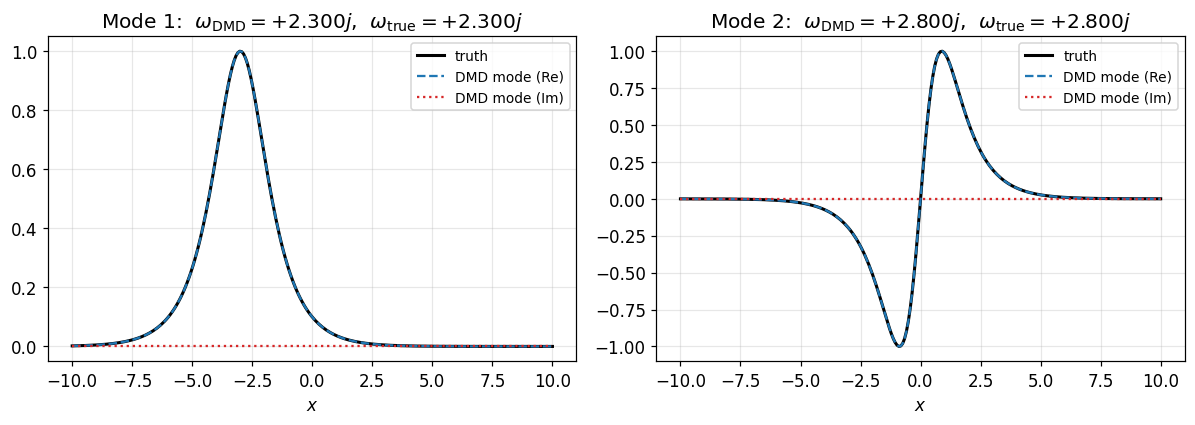

In [5]:
# Sort modes by imaginary part of omega (the frequency) - ascending
order   = np.argsort(om_dmd.imag)
Phi_s   = Phi_dmd[:, order]
om_s    = om_dmd[order]
b_s     = b_dmd[order]

# Match each mode's complex sign / phase to its analytic counterpart for plotting
truth_profiles = [phi1_true, phi2_true]
truth_omegas   = [omega1_true, omega2_true]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for j, ax in enumerate(axes):
    # phase-align: pick the scalar c that minimises ||c phi_dmd - phi_true||
    c = np.vdot(Phi_s[:, j], truth_profiles[j]) / np.vdot(Phi_s[:, j], Phi_s[:, j])
    aligned = c * Phi_s[:, j]
    ax.plot(x_grid, truth_profiles[j].real,  'k',  lw=2, label='truth')
    ax.plot(x_grid, aligned.real, 'C0--',          label='DMD mode (Re)')
    ax.plot(x_grid, aligned.imag, 'C3:',           label='DMD mode (Im)')
    ax.set_xlabel('$x$')
    ax.set_title(f'Mode {j+1}:  '
                 f'$\\omega_{{\\rm DMD}}={om_s[j].imag:+.3f}j$,  '
                 f'$\\omega_{{\\rm true}}={truth_omegas[j].imag:+.3f}j$')
    ax.legend(fontsize=9)
fig.tight_layout(); plt.show()


## 1.4 Predict: reconstruct the solution at a held-out time

The training window was $t \in [0,\,4\pi]$.  We now ask the DMD model to
predict $u(x, t^\star)$ at $t^\star = 5\pi$ — strictly outside the training
range.  Because the underlying dynamics is linear with purely imaginary
eigenvalues, DMD should *extrapolate* essentially to machine precision.


t*    = 15.7080    (training ended at 12.5664)
||u_DMD - u_true||_inf       = 2.70e-14
||u_DMD - u_true||_2 / ||u||  = 2.13e-14


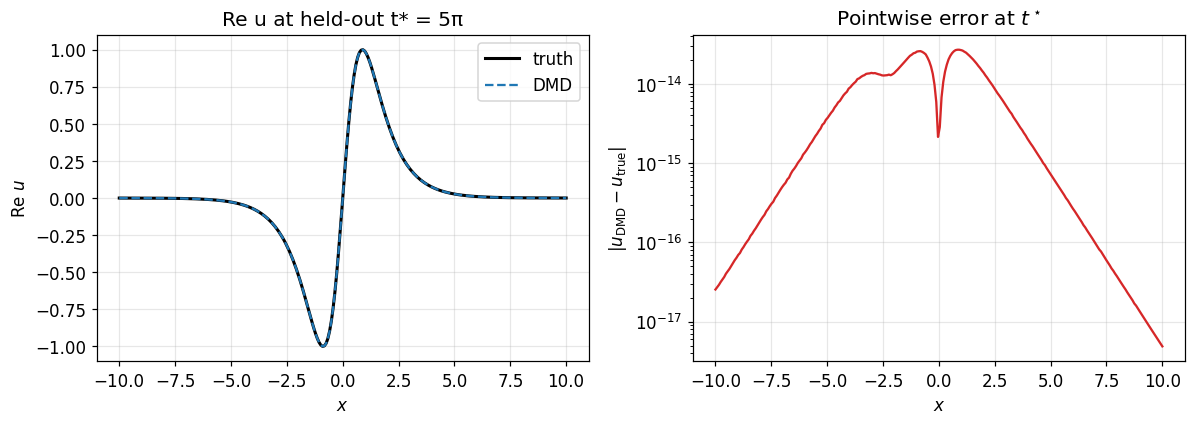

In [6]:
t_star    = 5 * np.pi                      # held-out, *outside* training window
u_true_t  = u_true(t_star)[:, 0]
u_pred_t  = dmd_predict(Phi_dmd, om_dmd, b_dmd, np.array([t_star]))[:, 0]

err_inf = np.max(np.abs(u_pred_t - u_true_t))
err_rel = np.linalg.norm(u_pred_t - u_true_t) / np.linalg.norm(u_true_t)
print(f't*    = {t_star:.4f}    (training ended at {t_train[-1]:.4f})')
print(f'||u_DMD - u_true||_inf       = {err_inf:.2e}')
print(f'||u_DMD - u_true||_2 / ||u||  = {err_rel:.2e}')

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(x_grid, u_true_t.real, 'k', lw=2, label='truth')
ax[0].plot(x_grid, u_pred_t.real, 'C0--', label='DMD')
ax[0].set_xlabel('$x$'); ax[0].set_ylabel(r'$\operatorname{Re}\,u$')
ax[0].set_title(f'Re u at held-out t* = 5\u03c0')
ax[0].legend()

ax[1].semilogy(x_grid, np.abs(u_pred_t - u_true_t) + 1e-300, 'C3')
ax[1].set_xlabel('$x$'); ax[1].set_ylabel(r'$|u_{\rm DMD} - u_{\rm true}|$')
ax[1].set_title('Pointwise error at $t^\\star$')
fig.tight_layout(); plt.show()


---
# 2. Koopman analysis via Extended DMD (EDMD)

The lecture's Koopman toy example is

$$\dot x_1 \;=\; \mu\,x_1, \qquad \dot x_2 \;=\; \lambda\,(x_2 - x_1^{2}),\qquad \mu < \lambda < 0.$$

In the lifted coordinates $(1,\,x_1,\,x_2,\,x_1^{2})$ the dynamics close
exactly: this dictionary is **Koopman-invariant**, so EDMD will recover the
analytic spectrum $\{0,\,\mu,\,\lambda,\,2\mu\}$ to machine precision.

**The plain DMD on this system would fail** because the nonlinear feedback
$x_1^{2}$ has no representation in the linear observable space $\{x_1, x_2\}$.

We pick $\mu = -0.05$, $\lambda = -1.0$.


## 2.1 Data generation

A single trajectory is enough to illustrate prediction, but the lifted
regression problem is much better conditioned with a *few* trajectories from
spread-out initial conditions, because a single trajectory rapidly collapses
onto the slow manifold $x_2 = \frac{\lambda}{\lambda - 2\mu} x_1^2$ and
then the four monomials $\{1, x_1, x_2, x_1^2\}$ become numerically
collinear.  We therefore stack five short trajectories.


Training trajectories tensor shape = (5, 2, 121)    (n_ic, 2, m+1)


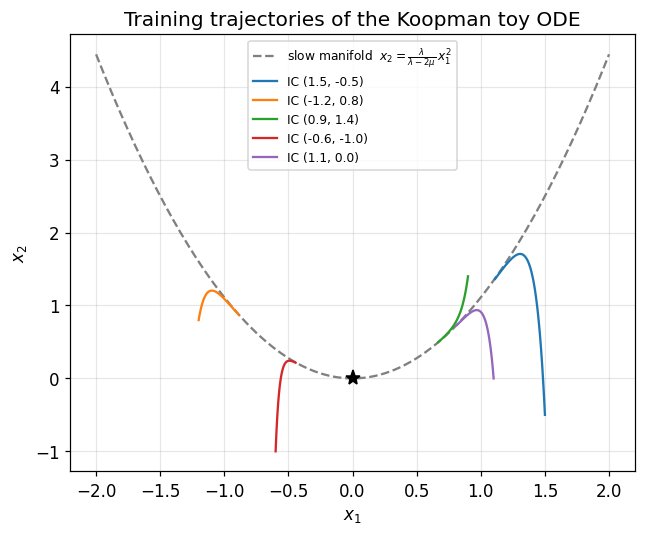

In [7]:
mu_true     = -0.05
lambda_true = -1.0

def koopman_rhs(t, x):
    x1, x2 = x
    return np.array([mu_true * x1,
                     lambda_true * (x2 - x1**2)])

# Training time grid
T_train_k = 6.0
dt_k      = 0.05
t_k       = np.arange(0.0, T_train_k + dt_k, dt_k)

# Five training initial conditions; t* = T_train_k + 4 dt is held-out
ic_list   = [(1.5, -0.5), (-1.2,  0.8), (0.9,  1.4),
             (-0.6, -1.0), (1.1,  0.0)]

X_block = np.stack([rk4(koopman_rhs, np.array(ic, dtype=float), t_k)
                    for ic in ic_list], axis=0)        # (n_ic, 2, len(t_k))
print('Training trajectories tensor shape =', X_block.shape, '   (n_ic, 2, m+1)')

# Plot the training trajectories in phase space
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
x1_grid = np.linspace(-2, 2, 200)
ax.plot(x1_grid,
        lambda_true / (lambda_true - 2*mu_true) * x1_grid**2,
        '--', color='gray', lw=1.5,
        label=r'slow manifold  $x_2 = \frac{\lambda}{\lambda - 2\mu}\,x_1^2$')
for k, ic in enumerate(ic_list):
    ax.plot(X_block[k, 0], X_block[k, 1], lw=1.5, label=f'IC {ic}')
ax.plot(0, 0, 'k*', ms=10)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_title('Training trajectories of the Koopman toy ODE')
ax.legend(fontsize=8); fig.tight_layout(); plt.show()


## 2.2 EDMD algorithm (annotated)

The dictionary $\boldsymbol\psi(\mathbf x) = (1,\, x_1,\, x_2,\, x_1^{2})^{\!\top}$
is rich enough to close the dynamics exactly.

1. Lift each snapshot column into observable space:
   $\boldsymbol\Psi_X = [\boldsymbol\psi(\mathbf x_0),\dots,\boldsymbol\psi(\mathbf x_{m-1})]$,
   similarly $\boldsymbol\Psi_{X'}$.
2. Solve the **Koopman matrix** by least-squares:
   $\mathbf K = \boldsymbol\Psi_{X'}\,\boldsymbol\Psi_{X}^{\dagger}\in\mathbb R^{N\times N}$.
3. Eigendecompose $\mathbf K$ to get **Koopman eigenvalues** $\lambda_j$
   (and the right eigenvectors that combine the dictionary into Koopman
   *modes*).
4. To get **Koopman eigenfunctions** $\varphi_j(\mathbf x) = \boldsymbol\xi_j^{\!\top}\,\boldsymbol\psi(\mathbf x)$
   we use the *left* eigenvectors of $\mathbf K$
   (equivalently the right eigenvectors of $\mathbf K^{\!\top}$).


In [8]:
def poly_dictionary(X):
    """Lift state X (shape 2 x m) to (1, x1, x2, x1^2)^T.  Returns 4 x m."""
    x1, x2 = X[0], X[1]
    return np.vstack([np.ones_like(x1), x1, x2, x1**2])

def edmd(X, Xp, dt, dictionary):
    """Extended DMD.

    Parameters
    ----------
    X, Xp : (n, m) arrays   snapshot pair in original state space.
    dt    : float
    dictionary : callable   X (n,m) -> Psi (N,m)

    Returns
    -------
    K           : (N, N) Koopman matrix (in observable space).
    Lambda      : (N,)   discrete-time eigenvalues of K.
    omega       : (N,)   continuous-time eigenvalues, log(Lambda)/dt.
    V_left      : (N, N) columns are LEFT eigvecs   ( -> eigenfunction coefs).
    Psi, Psip   : the lifted snapshot matrices (handy for diagnostics).
    """
    Psi  = dictionary(X)
    Psip = dictionary(Xp)
    K    = Psip @ np.linalg.pinv(Psi)            # least-squares Koopman matrix
    Lambda, _   = np.linalg.eig(K)
    Lam_l, V_l  = np.linalg.eig(K.T)             # left = right eig of K^T
    # match orderings -- sort all by Re(omega)
    omega = np.log(Lambda) / dt
    return K, Lambda, omega, V_l, Lam_l, Psi, Psip


In [9]:
# Build snapshot pair by stacking ALL training trajectories side-by-side
X_all  = np.concatenate([X_block[k, :, :-1] for k in range(len(ic_list))], axis=1)
Xp_all = np.concatenate([X_block[k, :,  1:] for k in range(len(ic_list))], axis=1)

K, Lam_K, om_K, Wleft, Lam_left, Psi, Psip = edmd(X_all, Xp_all, dt_k,
                                                  poly_dictionary)

# Pretty-print the spectrum, sorted by decreasing Re(omega)
analytic = {0.0: '0', mu_true: 'mu', lambda_true: 'lambda', 2*mu_true: '2 mu'}
def _closest(o):
    keys = list(analytic.keys())
    return analytic[keys[int(np.argmin(np.abs(np.array(keys) - o)))]]

order_K = np.argsort(om_K.real)[::-1]
print('Koopman matrix K =')
print(K)
print('\n Koopman continuous-time eigenvalues (sorted, slow first):')
for j in order_K:
    print(f'   omega = {om_K[j].real:+.6f}   (analytic match: {_closest(om_K[j].real)})')

print('\n analytic spectrum :  0, mu = {:+.4f}, lambda = {:+.4f}, 2 mu = {:+.4f}'.format(
        mu_true, lambda_true, 2*mu_true))


Koopman matrix K =
[[ 1.      0.     -0.     -0.    ]
 [-0.      0.9975  0.      0.    ]
 [ 0.      0.      0.9512  0.0486]
 [ 0.     -0.     -0.      0.995 ]]

 Koopman continuous-time eigenvalues (sorted, slow first):
   omega = +0.000000   (analytic match: 0)
   omega = -0.050000   (analytic match: mu)
   omega = -0.100000   (analytic match: 2 mu)
   omega = -1.000000   (analytic match: lambda)

 analytic spectrum :  0, mu = -0.0500, lambda = -1.0000, 2 mu = -0.1000


## 2.3 Plot the highest (slowest) Koopman eigenfunctions

A Koopman eigenfunction has the closed form
$\varphi_j(\mathbf x) = \boldsymbol\xi_j^{\!\top}\,\boldsymbol\psi(\mathbf x)$,
where $\boldsymbol\xi_j$ is a left eigenvector of $\mathbf K$.  We sort
eigenvalues by $\operatorname{Re}\omega$ (slow first), then plot the *top
two non-trivial eigenfunctions* — the ones associated with $\omega = \mu$
and $\omega = \lambda$ — as contours over the $(x_1, x_2)$ plane.

The analytic eigenfunctions (lecture slide *Koopman toy example*) are

$$\varphi_\mu(\mathbf x) = x_1, \qquad
\varphi_\lambda(\mathbf x) = x_2 - \frac{\lambda}{\lambda - 2\mu}\,x_1^{2}.$$


Recovered Koopman eigenfunctions  (basis: 1, x1, x2, x1^2):
  omega = +0.0000    phi(x) ~ +1.000 1
  omega = -0.0500    phi(x) ~ +1.000 x1
  omega = -0.1000    phi(x) ~ +1.000 x1^2
  omega = -1.0000    phi(x) ~ -0.900 x2  +1.000 x1^2

analytic coefficient of x1^2 in phi_lambda  : -1.1111


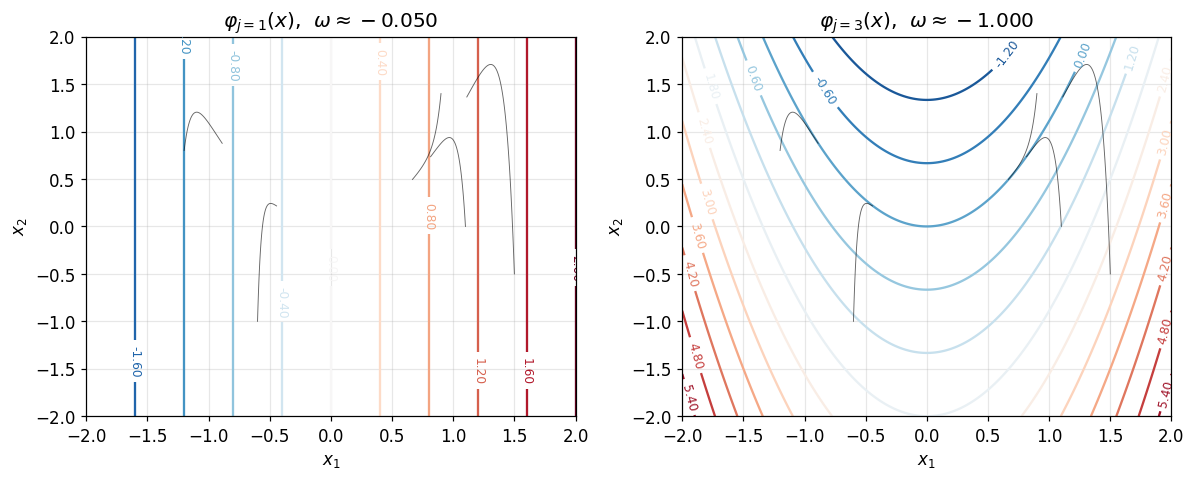

In [10]:
# Pair each (Lam_left, V_left) by the eigenvalue, then sort by Re(omega).
om_left  = (np.log(Lam_left) / dt_k).real
order_l  = np.argsort(om_left)[::-1]                # slow first
om_left  = om_left[order_l]
V_left   = Wleft[:, order_l]

names = ['1', 'x1', 'x2', 'x1^2']
print('Recovered Koopman eigenfunctions  (basis: 1, x1, x2, x1^2):')
for j in range(4):
    v = V_left[:, j]
    v = v / v[np.argmax(np.abs(v))]                  # normalise dominant entry
    terms = ['{:+.3f} {}'.format(c.real, n)
             for c, n in zip(v, names) if abs(c) > 1e-3]
    print(f'  omega = {om_left[j]:+.4f}    phi(x) ~ ' + '  '.join(terms))

print('\nanalytic coefficient of x1^2 in phi_lambda  : {:+.4f}'
      .format(-lambda_true / (lambda_true - 2*mu_true)))

# --- contour plot of the two slowest non-trivial eigenfunctions ----
def eigenfunction_on_grid(coef, X1, X2):
    return coef[0] + coef[1]*X1 + coef[2]*X2 + coef[3]*X1**2

X1, X2 = np.meshgrid(np.linspace(-2.0, 2.0, 200),
                     np.linspace(-2.0, 2.0, 200))

# Plot the two key non-trivial Koopman eigenfunctions emphasised in the
# lecture: phi_mu (with omega = mu, analytic = x1) and phi_lambda
# (with omega = lambda, analytic = x2 - lambda/(lambda-2mu) x1^2).
labels_for_plot = []
idx_mu     = int(np.argmin(np.abs(om_left - mu_true)))
idx_lambda = int(np.argmin(np.abs(om_left - lambda_true)))
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for plot_k, j in enumerate([idx_mu, idx_lambda]):
    coef = (V_left[:, j] / V_left[np.argmax(np.abs(V_left[:, j])), j]).real
    F    = eigenfunction_on_grid(coef, X1, X2)
    ax   = axes[plot_k]
    cs   = ax.contour(X1, X2, F, levels=12, cmap='RdBu_r')
    ax.clabel(cs, inline=True, fontsize=8, fmt='%.2f')
    for k in range(len(ic_list)):
        ax.plot(X_block[k, 0], X_block[k, 1], 'k', lw=0.6, alpha=0.6)
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
    ax.set_title(f'$\\varphi_{{j={j}}}(x)$,  $\\omega \\approx {om_left[j]:+.3f}$')
fig.tight_layout(); plt.show()


## 2.4 Reconstruct at a held-out time

We hold out a **fresh initial condition** $\mathbf x_0^\star = (1.0,\, 1.0)$
that does not appear in the training set, integrate the *true* dynamics with
RK4 to obtain $\mathbf x(t^\star)$ at a single held-out time $t^\star = 7$
(beyond the training horizon $T = 6$), and compare it to the EDMD prediction

$$\boldsymbol\psi(\hat{\mathbf x}(t^\star)) \;=\; \mathbf K^{\,t^\star/\Delta t}\,\boldsymbol\psi(\mathbf x_0^\star).$$


t_star = 7.0     (training stopped at T = 6.0)
  truth                  x(t*) = [0.7047 0.5517]
  EDMD prediction        x(t*) = [0.7047 0.5517]
  L2 error |EDMD - truth| = 2.61e-13


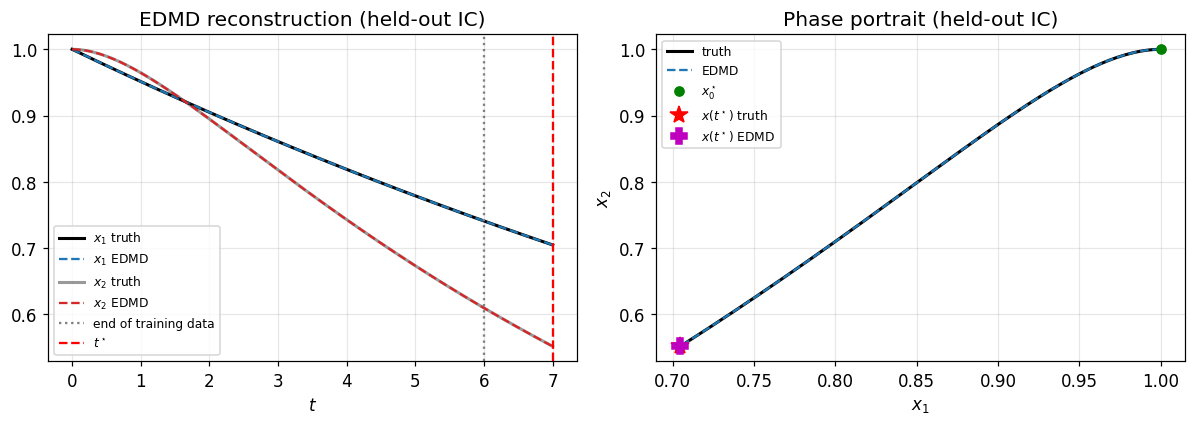

In [11]:
x0_star = np.array([1.0, 1.0])
t_star_k = 7.0                              # > T_train_k = 6.0 ;  held-out
n_step   = int(round(t_star_k / dt_k))

# truth via RK4
t_dense  = np.arange(0.0, t_star_k + dt_k, dt_k)
X_truth  = rk4(koopman_rhs, x0_star, t_dense)

# EDMD: lift, push K^n_step, decode
psi0    = poly_dictionary(x0_star.reshape(2, 1))[:, 0]
K_pow   = np.linalg.matrix_power(K, n_step)
psi_pred = K_pow @ psi0
x_edmd_at_tstar = np.array([psi_pred[1], psi_pred[2]])

# Roll out the lifted state at every step for a continuous trace
psi_traj = np.zeros((4, n_step + 1))
psi_traj[:, 0] = psi0
for k in range(n_step):
    psi_traj[:, k+1] = K @ psi_traj[:, k]
X_edmd_traj = psi_traj[1:3, :]

print(f't_star = {t_star_k}     (training stopped at T = {T_train_k})')
print(f'  truth                  x(t*) = {X_truth[:, n_step]}')
print(f'  EDMD prediction        x(t*) = {x_edmd_at_tstar}')
print(f'  L2 error |EDMD - truth| = {np.linalg.norm(x_edmd_at_tstar - X_truth[:, n_step]):.2e}')

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(t_dense, X_truth[0], 'k',    lw=2,   label='$x_1$ truth')
ax[0].plot(t_dense, X_edmd_traj[0], 'C0--',     label='$x_1$ EDMD')
ax[0].plot(t_dense, X_truth[1], 'k', alpha=0.4, lw=2, label='$x_2$ truth')
ax[0].plot(t_dense, X_edmd_traj[1], 'C3--',     label='$x_2$ EDMD')
ax[0].axvline(T_train_k, ls=':', color='gray', label='end of training data')
ax[0].axvline(t_star_k,  ls='--', color='red', label=r'$t^\star$')
ax[0].set_xlabel('$t$'); ax[0].set_title('EDMD reconstruction (held-out IC)')
ax[0].legend(fontsize=8)

ax[1].plot(X_truth[0], X_truth[1], 'k', lw=2, label='truth')
ax[1].plot(X_edmd_traj[0], X_edmd_traj[1], 'C0--', label='EDMD')
ax[1].plot(*x0_star, 'go', label=r'$x_0^\star$')
ax[1].plot(*X_truth[:, n_step], 'r*', ms=12, label=r'$x(t^\star)$ truth')
ax[1].plot(*x_edmd_at_tstar,    'mP', ms=10, label=r'$x(t^\star)$ EDMD')
ax[1].set_xlabel('$x_1$'); ax[1].set_ylabel('$x_2$')
ax[1].set_title('Phase portrait (held-out IC)')
ax[1].legend(fontsize=8)
fig.tight_layout(); plt.show()


---
# 3. SINDy --- Lorenz-63 example

We now demonstrate the lecture's *SINDy* example: recover the symbolic
right-hand side of the **Lorenz-63 system**

$$\dot x = \sigma(y - x), \qquad \dot y = x(\rho - z) - y, \qquad \dot z = xy - \beta z,$$

with $(\sigma, \rho, \beta) = (10, 28, 8/3)$, from a single noisy
trajectory.  We use the polynomial library up to degree 2 in $(x,y,z)$,
i.e. 10 candidate terms

$$\boldsymbol\Theta(\mathbf X) = [\,\mathbf 1,\, x,\, y,\, z,\, x^2,\, xy,\, xz,\, y^2,\, yz,\, z^2\,],$$

and the **Sequentially Thresholded Least Squares (STLSQ)** solver of
Brunton, Proctor & Kutz (2016).


Lorenz training data shape : (12500, 3)    (m, 3)


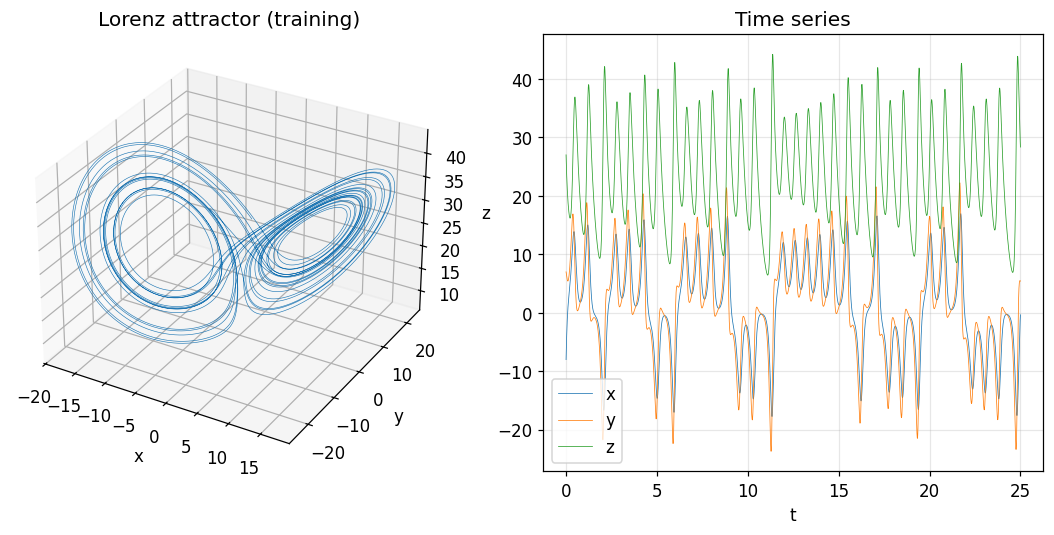

In [12]:
# --- Lorenz-63 right-hand side ------------------------------------
sigma, rho, beta = 10.0, 28.0, 8.0/3.0
def lorenz_rhs(t, x):
    return np.array([sigma * (x[1] - x[0]),
                     x[0] * (rho - x[2]) - x[1],
                     x[0] * x[1] - beta * x[2]])

# --- Generate training trajectory ---------------------------------
T_lorenz, dt_l = 25.0, 0.002             # fine grid for accurate derivatives
t_l = np.arange(0.0, T_lorenz, dt_l)
x0_l = np.array([-8.0, 7.0, 27.0])
X_l = rk4(lorenz_rhs, x0_l, t_l).T        # shape (m, 3)
print('Lorenz training data shape :', X_l.shape, '   (m, 3)')

# --- Numerical time-derivative via centered finite differences ----
# (For real noisy data, swap for a Savitzky-Golay or weak form.)
dX_l = np.gradient(X_l, dt_l, axis=0)

# Plot the famous butterfly
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1, 2, 1, projection='3d')
ax.plot(X_l[:, 0], X_l[:, 1], X_l[:, 2], lw=0.4)
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax.set_title('Lorenz attractor (training)')

ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(t_l, X_l[:, 0], lw=0.5, label='x')
ax2.plot(t_l, X_l[:, 1], lw=0.5, label='y')
ax2.plot(t_l, X_l[:, 2], lw=0.5, label='z')
ax2.set_xlabel('t'); ax2.set_title('Time series'); ax2.legend()
fig.tight_layout(); plt.show()


## 3.1 Polynomial library and STLSQ solver


In [13]:
def poly_library_3d(X):
    """Polynomial library up to degree 2 for n=3:
       columns = [1, x, y, z, x^2, xy, xz, y^2, yz, z^2].
       Input X: (m, 3).  Output: (m, 10).
    """
    x, y, z = X[:, 0], X[:, 1], X[:, 2]
    cols = [np.ones_like(x), x, y, z,
            x*x, x*y, x*z, y*y, y*z, z*z]
    names = ['1', 'x', 'y', 'z',
             'x^2', 'x y', 'x z', 'y^2', 'y z', 'z^2']
    return np.vstack(cols).T, names


def stlsq(Theta, dXdt, lam, n_iter=20):
    """Sequentially Thresholded Least Squares  (Brunton-Proctor-Kutz 2016).

    1. Initial fit:  Xi = pinv(Theta) @ dXdt
    2. Repeat n_iter times:
         - Zero out coefficients with |Xi_ij| < lam.
         - For each output column j, refit on its currently-active rows.
    """
    Xi = np.linalg.lstsq(Theta, dXdt, rcond=None)[0]
    n_outputs = dXdt.shape[1]
    for _ in range(n_iter):
        small = np.abs(Xi) < lam
        Xi[small] = 0.0
        for j in range(n_outputs):
            big = ~small[:, j]
            if big.sum() == 0:
                continue
            Xi[big, j] = np.linalg.lstsq(Theta[:, big], dXdt[:, j],
                                         rcond=None)[0]
    return Xi


In [14]:
# Build library and run STLSQ
Theta, lib_names = poly_library_3d(X_l)
print('cond(Theta) =', f'{np.linalg.cond(Theta):.3e}')

lam_sindy = 0.05
Xi = stlsq(Theta, dX_l, lam=lam_sindy, n_iter=20)
print(f'\nSINDy threshold lam = {lam_sindy}')
print('Coefficient matrix Xi (rows = library terms, cols = (x, y, z)):')
print(np.array2string(Xi, formatter={'float_kind':lambda v: f'{v:+8.3f}'}))


cond(Theta) = 8.433e+03

SINDy threshold lam = 0.05
Coefficient matrix Xi (rows = library terms, cols = (x, y, z)):
[[  +0.000   +0.000   +0.000]
 [  -9.999  +27.992   +0.000]
 [  +9.999   -0.999   +0.000]
 [  +0.000   +0.000   -2.666]
 [  +0.000   +0.000   +0.000]
 [  +0.000   +0.000   +1.000]
 [  +0.000   -1.000   +0.000]
 [  +0.000   +0.000   +0.000]
 [  +0.000   +0.000   +0.000]
 [  +0.000   +0.000   +0.000]]


In [15]:
# Pretty-print the recovered ODE and compare to truth
print('Discovered ODE:')
for k, comp in enumerate(['x', 'y', 'z']):
    terms = ['{:+.4f} {}'.format(Xi[i, k], lib_names[i])
             for i in range(len(lib_names)) if abs(Xi[i, k]) > 0]
    print('  d{}/dt = '.format(comp) + (' '.join(terms) if terms else '0'))

print('\nTrue Lorenz-63:')
print(f'  dx/dt = {-sigma:+.4f} x  {sigma:+.4f} y')
print(f'  dy/dt = {rho:+.4f} x  -1.0000 y  -1.0000 x z')
print(f'  dz/dt = {-beta:+.4f} z  +1.0000 x y')


Discovered ODE:
  dx/dt = -9.9990 x +9.9990 y
  dy/dt = +27.9922 x -0.9985 y -0.9998 x z
  dz/dt = -2.6663 z +0.9999 x y

True Lorenz-63:
  dx/dt = -10.0000 x  +10.0000 y
  dy/dt = +28.0000 x  -1.0000 y  -1.0000 x z
  dz/dt = -2.6667 z  +1.0000 x y


## 3.2 Validate by simulating the discovered model

We integrate the SINDy-recovered ODE forward from a held-out initial condition
and compare to the truth.  In the chaotic Lorenz regime the two trajectories
will eventually diverge — chaos is sensitive to initial conditions, not to model
recovery — but they should agree for several Lyapunov times.


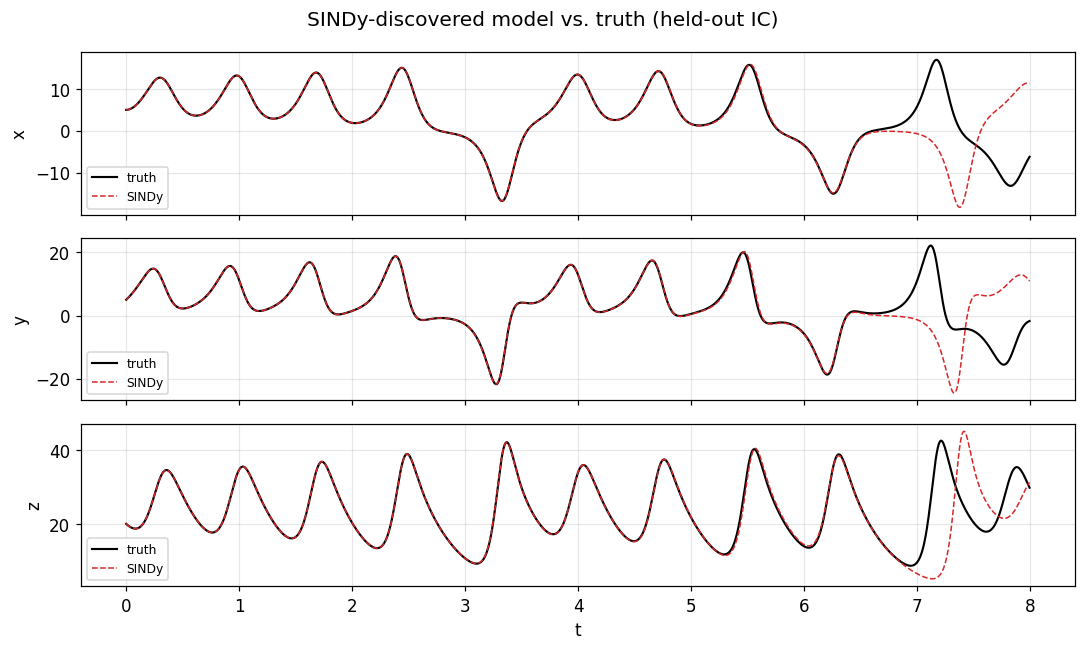

In [16]:
def sindy_rhs(t, x, Xi):
    Theta_x, _ = poly_library_3d(np.atleast_2d(x))
    return (Theta_x @ Xi).flatten()

x0_test  = np.array([5.0, 5.0, 20.0])      # held-out initial condition
T_test   = 8.0
t_test   = np.arange(0.0, T_test, dt_l)
X_truth_test = rk4(lorenz_rhs,                                  x0_test, t_test)
X_sindy_test = rk4(lambda t, x: sindy_rhs(t, x, Xi),            x0_test, t_test)

fig, ax = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
labels = ['x', 'y', 'z']
for k in range(3):
    ax[k].plot(t_test, X_truth_test[k], 'k',  lw=1.4, label='truth')
    ax[k].plot(t_test, X_sindy_test[k], 'C3--', lw=1.0, label='SINDy')
    ax[k].set_ylabel(labels[k]); ax[k].legend(loc='best', fontsize=8)
ax[-1].set_xlabel('t')
fig.suptitle('SINDy-discovered model vs. truth (held-out IC)')
fig.tight_layout(); plt.show()


---
# 4. Summary

| Method | Recovers | What we plotted | Held-out reconstruction |
|---|---|---|---|
| **DMD**      | best-fit linear operator on raw state               | 2 modes (matching $\operatorname{sech}(x+3)$ and $2\operatorname{sech}(x)\tanh(x)$) | $u(x, 5\pi)$ outside training window |
| **EDMD/Koopman** | linear operator on a richer dictionary of observables | 2 slowest non-trivial Koopman eigenfunctions | $\mathbf x(7)$ from a held-out IC, beyond training horizon |
| **SINDy**    | sparse symbolic ODE                                  | (recovered Lorenz coefficients)              | trajectory from held-out IC |

**Take-aways from the lecture (§DMD/§Koopman/§SINDy):**

- DMD is exact whenever the dictionary $\{x_1,\dots,x_n\}$ already closes the dynamics — as in the linear travelling-wave example.
- Koopman/EDMD extends DMD by enriching the dictionary; with a Koopman-invariant basis the recovery is again exact.
- SINDy recovers an *equation*, not just an operator, by solving a sparse regression problem in a polynomial library.

For extensions (PDE-FIND, weak SINDy, neural Koopman, HAVOK) see Part II of the lecture.
